Import the functions needed from MINGLE.

In [1]:
from MINGLE.pp.preprocessing import read_file
from MINGLE.pl._utils import save_figure
import MINGLE as mg
import scanpy as sc
import os

Load in dataset and set path to save figure to. 

In [2]:
OUTPUT_DIR = r"C:\Users\annet\Documents\Projects\MINGLE_Outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ensure save_figure writes here (scanpy-style)
sc.settings.figdir = OUTPUT_DIR

DATA_PATH = r"Z:\MINGLE\Data\Intestine\05_25_HuBMAP_tunit.csv"
adata_local = read_file(DATA_PATH)

C:\Users\annet\Documents\Projects\MINGLE-Annette\MINGLE_scverse\MINGLE\src\MINGLE\pp\preprocessing.py:34: DtypeWarning: Columns (62,63,70) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
c:\Users\annet\anaconda3\envs\annette_MINGLE\Lib\functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Calculate centroids.

In [3]:
centroids = mg.tl.centroid_Calculation(
            adata_local,
            cluster_col="Cell Type",
            neighborhood_col="Neighborhood",
        )

Calculate GMM with GPU.

In [4]:
adata = mg.tl.gpu_gmm_probability(
            adata_local,
            centroids,
            cluster_col="Cell Type",
            neighborhood_col="Neighborhood",
            k=10,
            batch_size=20000
        )

GPU Processing batch 1/126...
GPU Processing batch 2/126...
GPU Processing batch 3/126...
GPU Processing batch 4/126...
GPU Processing batch 5/126...
GPU Processing batch 6/126...
GPU Processing batch 7/126...
GPU Processing batch 8/126...
GPU Processing batch 9/126...
GPU Processing batch 10/126...
GPU Processing batch 11/126...
GPU Processing batch 12/126...
GPU Processing batch 13/126...
GPU Processing batch 14/126...
GPU Processing batch 15/126...
GPU Processing batch 16/126...
GPU Processing batch 17/126...
GPU Processing batch 18/126...
GPU Processing batch 19/126...
GPU Processing batch 20/126...
GPU Processing batch 21/126...
GPU Processing batch 22/126...
GPU Processing batch 23/126...
GPU Processing batch 24/126...
GPU Processing batch 25/126...
GPU Processing batch 26/126...
GPU Processing batch 27/126...
GPU Processing batch 28/126...
GPU Processing batch 29/126...
GPU Processing batch 30/126...
GPU Processing batch 31/126...
GPU Processing batch 32/126...
GPU Processing ba

Run positive probabilities plotting script.

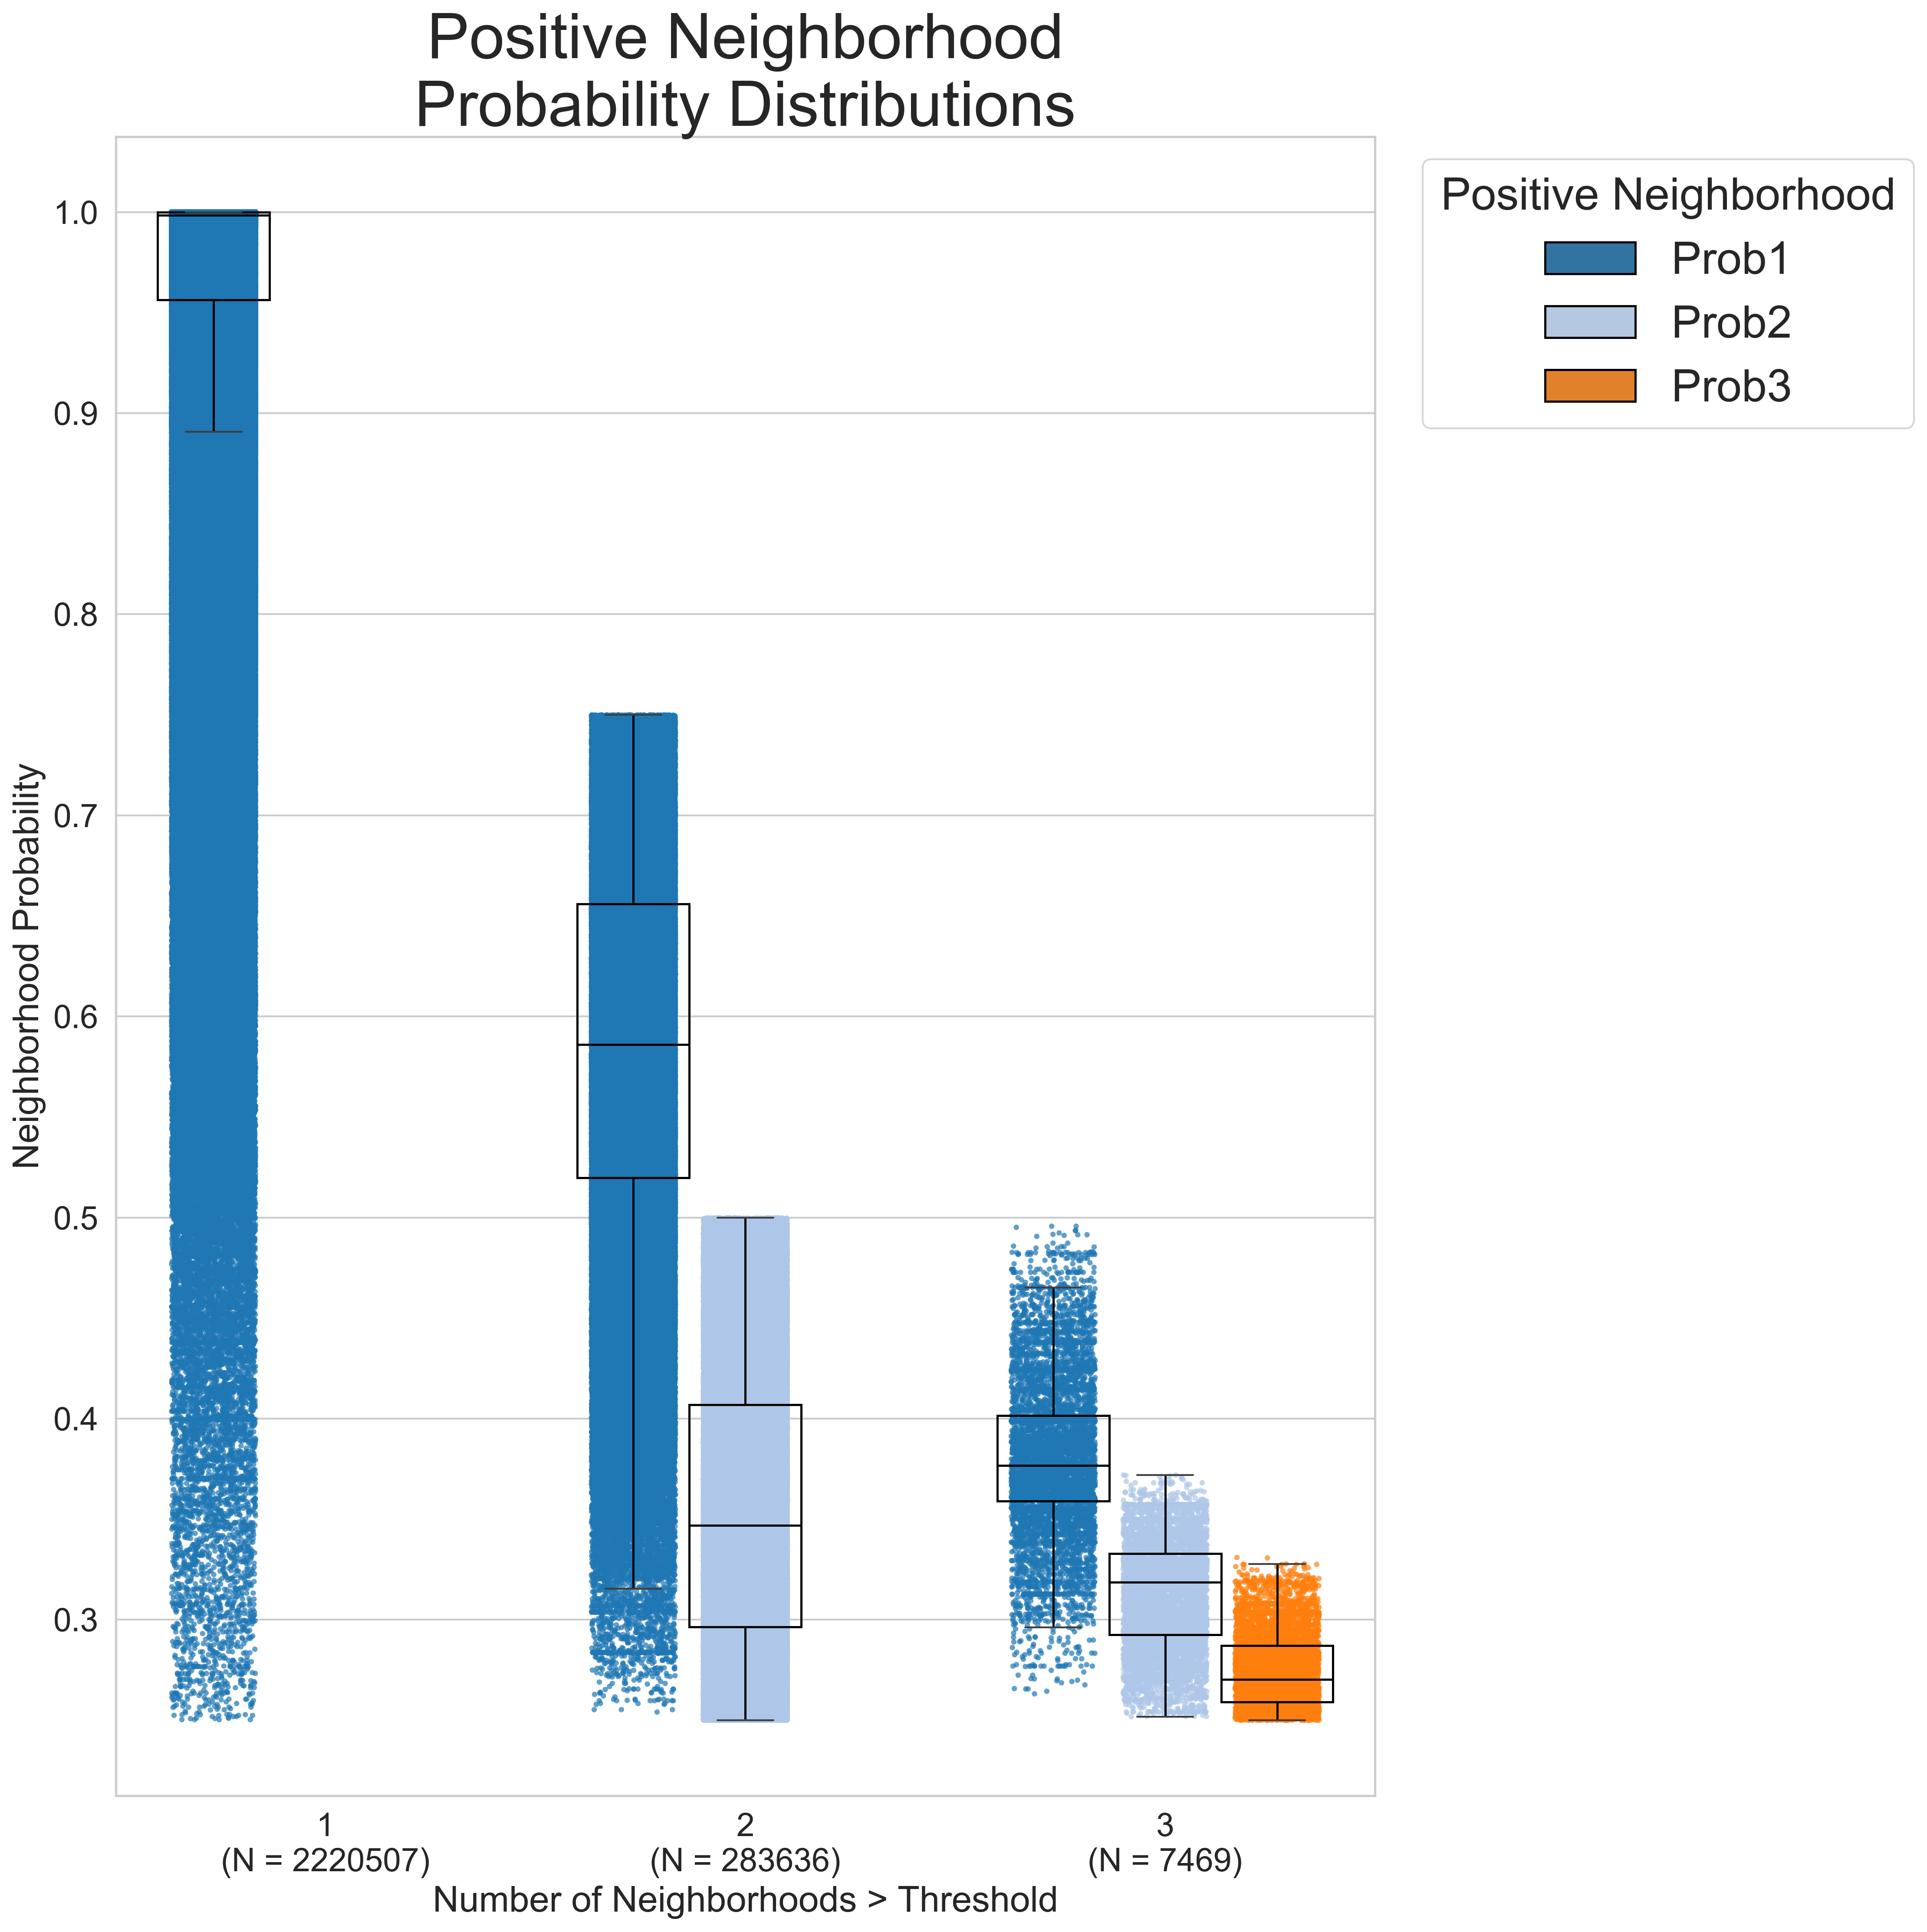

In [5]:
figs = mg.pl.edges_positive_probability(
            adata,
            prob_key="neighborhood_probabilities",
            threshold=0.25,
            save="png",
            show=True
        )

Save figure.

In [ ]:
# save figures 
if isinstance(figs, (list, tuple)) and len(figs) == 3:
    names = ["scatter", "counts_legend", "color_legend"]
else:
    names = [f"fig{i+1}" for i in range(len(figs))]

for fig, name in zip(figs, names):
    base = f"border_enrichment_{N1.replace(' ','_')}_{N2.replace(' ','_')}_{name}"
    save_figure(fig, base=base, save=True)
    print("Saved:", os.path.join(OUTPUT_DIR, base))